# Debugging

In [1]:
import pandas as pd
import geopandas as gpd
import shapely
import numpy as np
import json
import os
from functools import partial
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

import nomad.io.base as loader
import nomad.stop_detection.utils as utils
from nomad.stop_detection.density_based import seqscan_labels

import nomad.visit_attribution.visit_attribution as visits
import nomad.filters as filters
import nomad.city_gen as cg

from nomad.map_utils import blocks_to_mercator_gdf
from nomad.contact_estimation import compute_stop_detection_metrics
from nomad.stop_detection.viz import plot_stops_barcode, plot_time_barcode, plot_stops, plot_pings, _plot_base_geometry, plot_circles

In [2]:
with open('config_beta_5.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

In [3]:
poi_table = gpd.read_parquet(config["buildings_file"]).rename(columns={"id":"location"})
sparse_df = loader.from_file(config["output_files"]["sparse_path"], format="parquet")
diaries_df = loader.from_file(config["output_files"]["diaries_path"], format="parquet").rename(
    columns={"identifier":"user_id"})

In [4]:
sparse_df = sparse_df[sparse_df['user_id'] == 'agitated_angry_colden']
sparse_df.drop(columns=['datetime'], inplace=True)
diaries_df = diaries_df[diaries_df['user_id'] == 'agitated_angry_colden']

In [56]:
# Parameters
output = seqscan_labels(
    sparse_df,
    dist_thresh=50,
    time_thres=90,
    min_pts=2,
    back_merge=False,
    return_cores=True,
    traj_cols={'x': 'x', 'y': 'y', 'timestamp': 'timestamp'}
)
sparse_df['cluster'] = output.cluster
#sparse_df['cluster'] = labels

In [57]:
if 'location' in sparse_df:
    sparse_df.drop(columns=["location"], inplace=True)
    
sparse_df["location"] = visits.point_in_polygon(
    data=sparse_df, 
    poi_table=poi_table.loc[poi_table.location.isin(['w-x17-y10', 'r-x19-y11'])], 
    data_crs='EPSG:3857',
    max_distance=20, 
    location_id='location', 
    method='centroid',
    x='x', 
    y='y'
)

In [58]:
summarize_stops_with_loc = partial(
    utils.summarize_stop,
    x='x',
    y='y',
    keep_col_names=False,
    passthrough_cols=['location'],
    complete_output=False)

stops = sparse_df[sparse_df.cluster!=-1].groupby('cluster', as_index=False).apply(
            summarize_stops_with_loc, include_groups=False)
stops

,cluster,x,y,start_timestamp,duration,location
0,0,-4.265429e+06,4.393147e+06,1717214485,173,w-x17-y10


In [49]:
diaries_df

,datetime,timestamp,duration,location,user_id,x,y,tz_offset
381,2024-06-01 00:00:12,1717214412,90,w-x17-y10,agitated_angry_colden,-4265429.0,4393133.5,-14400
382,2024-06-01 01:30:12,1717219812,0,None,agitated_angry_colden,NaN,NaN,-14400
383,2024-06-01 01:31:00,1717219860,89,r-x19-y11,agitated_angry_colden,-4265414.0,4393148.5,-14400


In [13]:
metrics = compute_stop_detection_metrics(
            stops=stops,
            truth=diaries_df,
            user_id='serene_yalow',
            algorithm='seqscan',
            traj_cols={'location_id': 'location'},
            timestamp='timestamp'
        )
metrics

/Users/andresmondragon/nomad/nomad/io/base.py:129: UserWarning: Trajectory column 'timestamp' specified for 'timestamp' not found in DataFrame.
  warnings.warn(f"Trajectory column '{value}' specified for '{key}' not found in DataFrame.")


{'precision': np.float64(0.9072164948453608),
 'recall': np.float64(0.49162011173184356),
 'f1': np.float64(0.6376811594202898),
 'user_id': 'serene_yalow',
 'algorithm': 'seqscan'}

In [14]:
backup = sparse_df

In [ ]:
# sparse_df = backup.query("1717217428 > timestamp > 1717214412")
# sparse_df = backup

[]

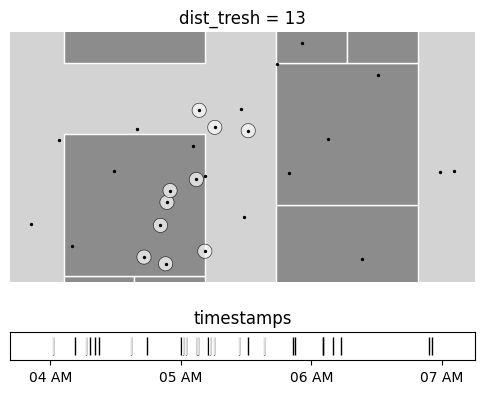

In [22]:
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,4.5),
                                         gridspec_kw={'height_ratios':[10,1]})
# Plot colored pings
ax_map.set_title("dist_tresh = 13")
plot_circles(sparse_df, ax=ax_map, radius=1.5, color='cluster', cmap='PiYG', base_geometry=poi_table, base_geom_color='#8c8c8c', base_geom_background='#d3d3d3')
plot_pings(sparse_df, ax=ax_map, s=2, color='black')
plot_time_barcode(sparse_df['timestamp'], ax=ax_barcode, set_xlim=True)
plot_time_barcode(sparse_df, color='cluster', ax=ax_barcode, cmap='PiYG', set_xlim=False, lw=1.3)

#plot_stops_barcode(diaries_df.dropna(), ax=ax_barcode, stop_alpha=0.6, cmap='inferno_r', set_xlim=False, timestamp='timestamp')

ax_barcode.set_title("timestamps")

plt.plot()